In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import torch
%matplotlib inline
plt.style.use("seaborn-v0_8-white")
sns.set_style("ticks")
sns.set_palette("deep")

(discrete-random-variables)=
# Discrete Random Variables

## Probability spaces
We condition the probabilities on our current information $I$ in whatever we write below.
Because this information is always in the background, we will not explicitly show it in our notation.

Let's suppose we are doing an experiment.
It doesn't matter what precisely the experiment is.
The result of the experiment depends on a bunch of things denoted by $\omega$.
Some people call $\omega$ the **state of nature**.
This variable may be more than is needed for our experiment, but it is an excellent way to think about it.
In any case, the state of nature includes the physical variables that determine the result of the experiment.

The state of nature takes values in an enormous set $\Omega$.
So an $\omega_1$ may happen, an $\omega_2$ may occur, and so on, all included in $\Omega$.
We do not know which $\omega$ will happen.
We describe this uncertainty using something called a **probability measure**.

What is this probability measure?
It is a function that takes a subset $A$ of $\Omega$ and tells us how probable the state of nature will be in $A$.
We write this probability as $p(A)$.
When equipped with the probability measure $p$, the set $\Omega$ is called a **probability space**.

```{admonition} Okay, it is a bit more complicated than that.
:class: dropdown
The probability measure cannot always be defined over all subsets of $\Omega$.
It can only be defined over a particular set $\mathcal{F}$ of subsets of $\Omega$, which mathematicians call a **$\sigma$-algebra**.
Then the probability measure $p$ is a function from $\mathcal{F}$ to $[0,1]$ satisfying specific properties called the **Kolmogorov axioms**.
The triplet $(\Omega, \mathcal{F}, \mathbb{P})$ is called a **probability space**.
We will not go into the details of this.
You will have to take a course in measure theory to learn more about this.
```

## The mathematical definition of a random variable

Call $X$ the result of the experiment.
It is, say, the number we read in a measuring device.
What does the measuring device do?
Well, it takes the state of nature $\omega$ and maps it to a number $X(\omega)$.
That's why the mathematicians define a random variable as a function from $\Omega$ to some set of values.

```{admonition} Okay again, it is a bit more complicated than that.
:class: dropdown
The set of values is not just any set.
It is a set that is equipped with a $\sigma$-algebra and a probability measure.
This set is called the **state space** of the random variable.
The random variable has to be a measurable function from $\Omega$ to the state space.
```

Depending on the values that $X$ takes, we can classify it into several types:
+ If $X(\omega)$ takes discrete values, like heads or tails, $0, 1, 2$, etc., then we say that $X$ is a discrete random variable.
+ If $X(\omega)$ takes continuous values, like values from zero to one, or all positive real numbers, we say that $X$ is a continuous random variable.
+ If $X(\omega)$ is a vector, then we say that $X$ is a random vector.
+ If $X(\omega)$ is a matrix, then we say that $X$ is a random matrix.
+ If $X(\omega)$ is a function, then we say that $X$ is a random process (or a stochastic process or a random field), and so on.

Notation:
+ We will use upper case letters to represent random variables, like $X, Y, Z$.
+ We will use lowercase letters to represent the values of random variables, like $x, y, z$.

### Example: The random variable corresponding to the result of a coin toss (1/2)

Let's consider the coin tossing example we introduced in [the previous lecture](coin-toss) again.
Recall that we denoted with $v_0$ and $\omega_0$ the coin's initial velocity and angular velocity.
These two ultimately determine the result of the experiment.
So $\omega = (v_0, \omega_0)$.
The result of the experiment $X$ is a function of $v_0$ and $\omega_0$:

$$
X(v_0,\omega_0) = 
\begin{cases}
T,&\;\text{if}\;\frac{2v_0\omega_0}{g} (\text{mod}\;2\pi) \in \left(\frac{\pi}{2},\frac{3\pi}{2}\right),\\
H,&\;\text{otherwise}.
\end{cases}
$$

You see that the result of the coin toss $X$ is nothing more but a function of the *true state of nature* $\omega = (v_0, \omega_0)$.
We reproduce the causal graph:

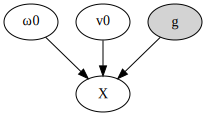

In [2]:
gct = Digraph('coin_toss_g')
gct.node('omega0', label='<&omega;<sub>0</sub>>')
gct.node('v0', label='<v<sub>0</sub>>')
gct.node('g', style='filled')
gct.node('X')
gct.edge('g', 'X')
gct.edge('v0', 'X')
gct.edge('omega0', 'X')
gct.render('coin_toss_g', format='png')
gct

### The probability mass function

We will now focus on the discrete random variable $X$.
The probability mass function of $X$ is a function that gives the probability of $X$ taking a particular value, say $x$.

Mathematicians write $f_X(x)$ for the probability mass function of $X$.
The subscript $X$ reminds us we are talking about the random variable $X$.
Everyone else writes $p(x)$ if there is no confusion about which random variable we are talking about.
We are going to follow the latter convention.

```{note}
If we wanted to show the background information, we would write $p(x|I)$.
```

We define the probability mass function in terms of the underlying probability space.
Here is how.
We define the set of states of nature that give an experiment with value $x$:

$$
(X=x) \equiv \{\omega \in \Omega: X(\omega) = x\}.
$$

Then the probability mass function is defined as:

$$
p(x) \equiv f_X(x) := p\left(X=x\right).
$$

```{note}
No one, except the mathematicians, cares about the underlying probability space.
It is there to rigorously define the probability mass function so that we can prove things about it.
In practice, we only care about the probability mass function.
If we have it, we can calculate any probability we want about the random variable.
```


### Properties of the probability mass function

There are some standard properties of the probability mass function that is worth memorizing:

+ It is nonnegative:

$$
p(x) \ge 0,
$$

for all $x$.
+ It is normalized:

$$
\sum_x p(x) = 1,
$$
where the summation is over all possible values $x$.

+ It is additive. Take any set of possible values of $X$, say $A$. The probability of $X$ taking values in $A$ is:

$$
p(X\in A) = \sum_{x\in A} p(x).
$$

### Example: The random variable corresponding to the result of a coin toss (2/2)

Suppose $X$ is the random variable corresponding to the result of the coin toss.
We will write $X=0$ if the result is heads and $X=1$ if the result is tails.
As mentioned earlier, we can directly work with the probability mass function instead of trying to define the underlying probability space.
For a fair coin, it makes intuitive sense that:

$$
p(X=0) = \text{probability of heads} = \frac{1}{2}.
$$

and

$$
p(X=1) = \frac{1}{2}.
$$

The probability that $X$ takes any other value is zero.

```{note}
We should be careful about the notation.
I said that $p(x)$ is the probability mass function of $X$.
It is a good notation when I want to talk about the entire function.
There is no ambiguity as $p(x)$ is the probability mass function of the random variable labeled by the capitalization of the letter $x$, i.e., $X$, evaluated at the lower case $x$.
But I cannot write $p(0)$ or $p(1)$ because then I do not know which random variable I am talking about.
So I wrote $p(X=0)$ and $p(X=1)$.
Some people write $p(x=0)$ and $p(x=1)$.
Mathematicians point out that this is an argument for using $f_X(x)$ instead of $p(x)$.
They have a point, but I'd save myself the trouble of always writing $f_X(x)$.
```

## Functions of discrete random variables

Let $X$ be a discrete random variable and $g$ be a function from the state space of $X$ to some other set.
We can now define a new random variable:

$$
Y = g(X).
$$

Let $g^{-1}(y)$ be the set of values of $X$ that map to $y$ through $g$:

$$
g^{-1}(y) := \{x: g(x) = y\}.
$$

Then, the probability mass function (pmf) of $Y$ is:

$$
p(y) = p(Y = y) = p(X\in g^{-1}(y)) = \sum_{x\in g^{-1}(y)} p(x),
$$

We have given the formal definition of the uncertainty propagation problem.
The correspondence is that $X$ represents the parameters of a causal model, and $Y = g(X)$ is the uncertain result of the causal model.



## Expectation of random variables

The expectation of a random variable is defined by:

$$
\mathbb{E}[X] = \sum_{x=0}^\infty x p(x).
$$

You can think of the expectation as the value of the random variable that one should "expect" to get.

### Example: Expectation of a coin toss
The expectation of the coin toss random variable is:

$$
\mathbb{E}[X] = 0\cdot p(X=0) + 1\cdot p(X=1) = 0.5.
$$

We should take the interpretation of the expectation with a grain of salt.
The expectation is not necessarily a value that the random variable can take.
It is weird to say that we "expect" to get $0.5$ when we toss a coin.

(properties-expectation)=
### Properties of the expectation
Here are some properties of the expectation.
+ Take any constant $c$. Then we have:

$$
\mathbb{E}[X + c] = \mathbb{E}[X] + c.
$$

```{admonition} Proof
:class: dropdown
This proof is a little bit trickier than it looks.
First, define the random variable:

$$
Y = X + c.
$$

The PMF of $Y$ is:

$$
p(y) = p(Y = y) = p(X + c = y) = p(X = y - c).
$$

Then we have:

$$
\begin{align}
\mathbb{E}[X + c] &= \mathbb{E}[Y]\\
&= \sum_y y p(y)\\
&= \sum_y y p(Y = y)\\
&= \sum_y y p(X = y - c).
\end{align}
$$

Now we change the variable of summation to $x = y - c$:

$$
\begin{align}
\mathbb{E}[X + c] &= \sum_y (x + c) p(X = x)\\
&= \sum_x x p(X = x) + c \sum_x p(X = x)\\
&= \mathbb{E}[X] + c,
\end{align}
$$

where in the last step we used the fact that the sum of the PMF is $1$.
```

+ For any $\lambda$ real number, we also have:

$$
\mathbb{E}[\lambda X] = \lambda \mathbb{E}[X].
$$

```{admonition} Proof
:class: dropdown
The proof is similar to the previous one.
But we need to work with the random variable:

$$
Y = \lambda X.
$$

```

+ Now consider any function $g(x)$.
We can now define the expectation of $g(X)$ as the expectation of the random variable $Y = g(X)$:

$$
\mathbb{E}[g(X)] = \sum_x g(x) p(x).
$$

```{admonition} Proof
:class: dropdown

The proof is the same as before but we are going with the more general random variable:

$$
Y = g(X).
$$

We have:

$$
\begin{align}
\mathbb{E}[g(X)] &= \mathbb{E}[Y]\\
&= \sum_y y p(y)\\
&= \sum_y y p(Y = y)\\
&= \sum_y y p(X\in g^{-1}(y))\\
&= \sum_y y \sum_{x\in g^{-1}(y)} p(x)\\
&= \sum_x \sum_{y=g(x)} y p(x)\\
&= \sum_x g(x) p(x).
\end{align}
$$
```

+ Assume that $g(x)$ is a convex function. 
Recall that a convex function is a function that looks like a bowl.
Then we have the Jensen's inequality:

$$
g\left(\mathbb{E}[X]\right) \le \mathbb{E}[g(X)].
$$

The proof is not trivial.

## Variance of random variables

The variance of a random variable $X$ is defined as the expectation of the square deviation from its expectation, i.e.:

$$
\mathbb{V}[X] := \mathbb{E}\left[(X - \mathbb{E}[X])^2\right].
$$

You can think of the variance as the spread of the random variable around its expectation.
However, take this with a grain of salt for discrete random variables.

### Example: Variance of a coin toss
Let's calculate the variance of the coin toss.
We need:

$$
\mathbb{E}\left[X^2\right] = 0^2\cdot p(X=0) + 1^2 \cdot p(X=1) = 0.5.
$$

So, using the formula above, we get the following:

$$
\mathbb{V}[X] = \mathbb{E}\left[X^2\right] - \left(\mathbb{E}[X]\right)^2 = 0.5 - (0.5)^2 = 0.5 - 0.25 = 0.25.
$$

(properties-variance)=
### Properties of the variance
Here are some properties of the variance.
+ It holds that:

$$
\mathbb{V}[X] = \mathbb{E}\left[X^2\right] - \left(\mathbb{E}[X]\right)^2.
$$

```{admonition} Proof
:class: dropdown
$$
\begin{align}
\mathbb{V}[X] &= \mathbb{E}\left[(X - \mathbb{E}[X])^2\right]\\
&= \mathbb{E}\left[X^2 - 2X\mathbb{E}[X] + \left(\mathbb{E}[X]\right)^2\right]\\
&= \mathbb{E}\left[X^2\right] - 2\mathbb{E}[X]\mathbb{E}[X] + \left(\mathbb{E}[X]\right)^2\\
&= \mathbb{E}\left[X^2\right] - \left(\mathbb{E}[X]\right)^2.
\end{align}
$$
```

We use this formula we use to calculate the variance in practice.

+ For any constant $c$, we have:

$$
\mathbb{V}[X + c] = \mathbb{V}[X].
$$

```{admonition} Proof
:class: dropdown
$$
\begin{align}
\mathbb{V}[X + c] &= \mathbb{E}\left[(X + c - \mathbb{E}[X + c])^2\right]\\
&= \mathbb{E}\left[(X + c - \mathbb{E}[X] - c)^2\right]\\
&= \mathbb{E}\left[(X - \mathbb{E}[X])^2\right]\\
&= \mathbb{V}[X].
\end{align}
$$
```

+ For any constant $c$, we have:

$$
\mathbb{V}[cX] = c^2\mathbb{V}[X].
$$

```{admonition} Proof
:class: dropdown
$$
\begin{align}
\mathbb{V}[cX] &= \mathbb{E}\left[(cX - \mathbb{E}[cX])^2\right]\\
&= \mathbb{E}\left[(cX - c\mathbb{E}[X])^2\right]\\
&= \mathbb{E}\left[c^2(X - \mathbb{E}[X])^2\right]\\
&= c^2\mathbb{E}\left[(X - \mathbb{E}[X])^2\right]\\
&= c^2\mathbb{V}[X].
\end{align}
$$
```

